In [45]:
import requests
import zipfile
import pathlib
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import torch

In [46]:
root_dir = pathlib.Path("./data")
image_dir = root_dir / "pizza_steak_sushi"

In [47]:
if image_dir.is_dir():
    print("Already exists skipping...")
else:
    image_dir.mkdir(parents = True, exist_ok = True)

with open(root_dir / "content.zip", "wb") as dl:
    response = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    dl.write(response.content)

with zipfile.ZipFile(root_dir / "content.zip", "r") as zip_ref:
    zip_ref.extractall(image_dir)

Already exists skipping...


In [48]:
from PIL import Image

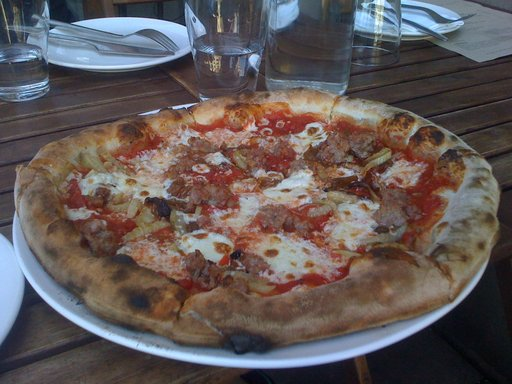

In [49]:
Image.open(image_dir / "train" / "pizza" / "5764.jpg")

In [50]:
def walk_thorugh_dir(dir_name):
    for root, dir, files in os.walk(dir_name):
     print(f"Root files: {root} | DirFiles: {dir} | Images: {len(files)}")

walk_thorugh_dir(image_dir)

Root files: data/pizza_steak_sushi | DirFiles: ['test', 'train'] | Images: 0
Root files: data/pizza_steak_sushi/test | DirFiles: ['steak', 'sushi', 'pizza'] | Images: 0
Root files: data/pizza_steak_sushi/test/steak | DirFiles: [] | Images: 19
Root files: data/pizza_steak_sushi/test/sushi | DirFiles: [] | Images: 31
Root files: data/pizza_steak_sushi/test/pizza | DirFiles: [] | Images: 25
Root files: data/pizza_steak_sushi/train | DirFiles: ['steak', 'sushi', 'pizza'] | Images: 0
Root files: data/pizza_steak_sushi/train/steak | DirFiles: [] | Images: 75
Root files: data/pizza_steak_sushi/train/sushi | DirFiles: [] | Images: 72
Root files: data/pizza_steak_sushi/train/pizza | DirFiles: [] | Images: 78


In [51]:
image_path_list = list(image_dir.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)

classes = random_image_path.parent.stem
# classes

img = Image.open(random_image_path)
# img

In [52]:
imgarray = np.asarray(img)
# imgarray

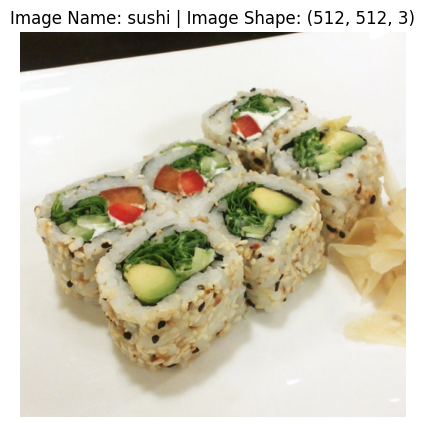

In [53]:
plt.figure(figsize = (10, 5))
plt.imshow(imgarray)
plt.title(f"Image Name: {str(classes)} | Image Shape: {imgarray.shape}")
# plt.inline(Flase)
plt.axis(False)
# plt.legend()
plt.show()

In [54]:
img_arrays = []

for img_path in image_path_list:
    # print(img_path)
    img = Image.open(img_path)
    img_array = np.asarray(img)
    img_class = img_path.parent.stem

    img_arrays.append((img_array, img_class))

In [56]:
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets
import torchvision.transforms.v2 as transforms

In [57]:
transform = transforms.Compose([
    transforms.Resize(size=[64, 64]),
    transforms.RandomHorizontalFlip(p = 0.5),
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale = True)
])

In [58]:
transformed_img = transform(img)

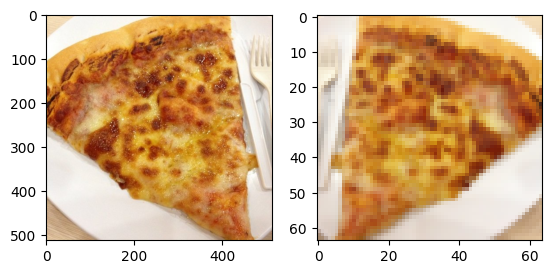

In [59]:
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.subplot(1, 2, 2)
plt.imshow(transformed_img.permute(1, 2, 0))

In [60]:
train_dir = image_dir / "train"
test_dir = image_dir / "test"

In [61]:
train_dataset =  datasets.ImageFolder(train_dir, transform = transform, target_transform = None)
test_dataset = datasets.ImageFolder(test_dir, transform = transform)

In [62]:
train_dataset, test_dataset

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                  Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomHorizontalFlip(p=0.5)
                  ToImage()
                  ToDtype(scale=True)
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                  Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
                  RandomHorizontalFlip(p=0.5)
                  ToImage()
                  ToDtype(scale=True)
            ))

In [63]:
classes = train_dataset.classes
classes

['pizza', 'steak', 'sushi']

In [64]:
test_dataset.classes

['pizza', 'steak', 'sushi']

In [65]:
train_dataset.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [66]:
train_loader = DataLoader(train_dataset,
                         shuffle = True,
                         batch_size = 32)

test_loader = DataLoader(test_dataset,
                        shuffle = False,
                        batch_size = 32)

In [67]:
image, target = next(iter(train_loader))

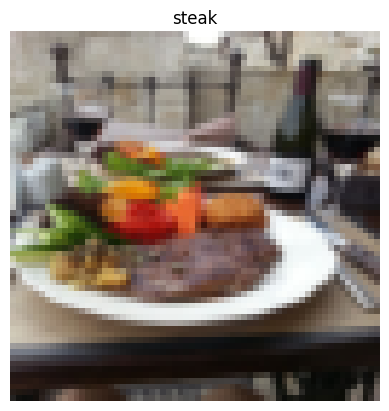

In [68]:
plt.imshow(image[0].permute(1, 2, 0))
plt.title(classes[target[0]])
plt.axis(False)
plt.show()

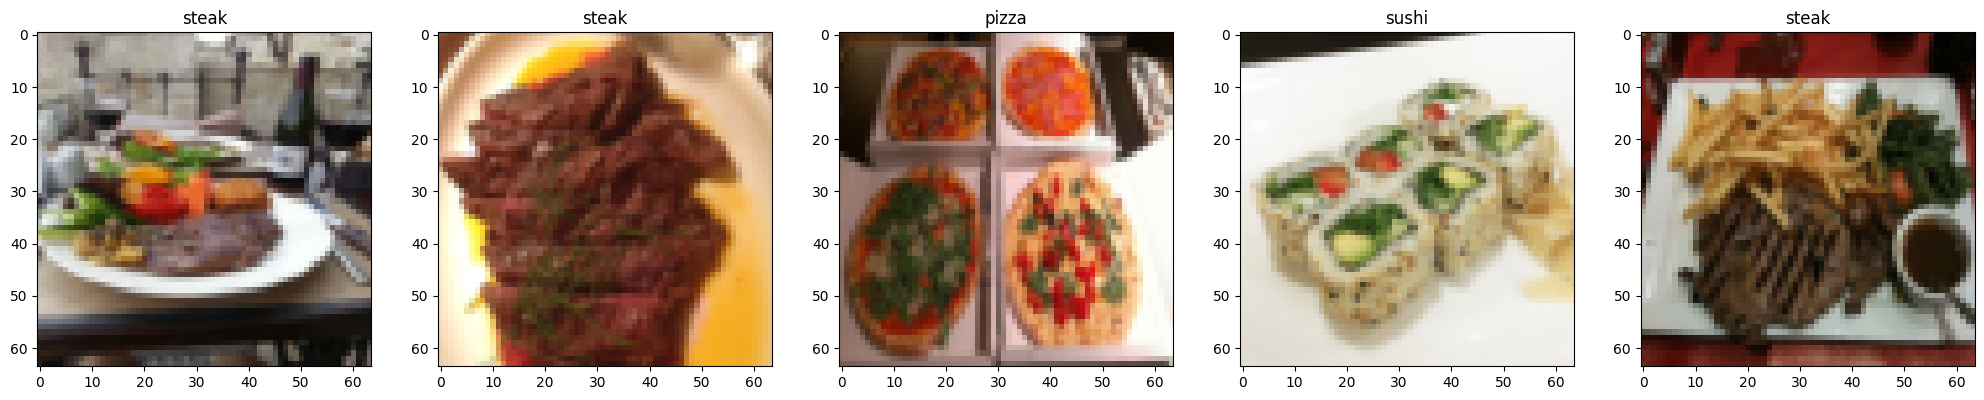

In [69]:
plt.figure(figsize = (25, 20))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(image[i].permute(1, 2, 0))
    plt.title(classes[target[i]])

In [70]:
def fetch_classes(dirname: str):
    classes = sorted(entry.name for entry in os.scandir(dirname) if dirname.is_dir())

    idx_classes = {k:i for i, k in enumerate(classes)}
    return classes, idx_classes

In [71]:
classes, idx_classes = fetch_classes(image_dir / "train")

idx_classes, classes

({'pizza': 0, 'steak': 1, 'sushi': 2}, ['pizza', 'steak', 'sushi'])

In [139]:
class CustomImageFolder(Dataset):
    def __init__(self, root: str = None, transform = None):
        super(CustomImageFolder, self).__init__()

        self.root = root
        self.annotation = list(self.root.glob('*/*.jpg'))
        self.classes, self.idx_classes = fetch_classes(root)
        self.transform  = transform
        self.samples = [
            (img_path, self.idx_classes[img_path.parent.stem])
            for img_path in self.annotation
            ]

    def __len__(self):
        return len(self.annotation)

    def __getitem__(self, index):
        image = Image.open(self.annotation[index]).convert("RGB")
        # self.samples.

        class_name = self.annotation[index].parent.stem
        class_idx = self.idx_classes[class_name]

        if self.transform:
            return self.transform(img), class_idx
        return img, class_idx

    def __repr__(self):
        return (f"CustomImageFolder \n   Number of Datapoints: {len(self.annotation)} \n"
        f"   Root Location: {self.root} \n"
        f"   Transforms: {self.transform}")
        

In [140]:
custom_train_dataset = CustomImageFolder(train_dir, transform)
custom_test_dataset = CustomImageFolder(test_dir, transform)

custom_train_dataset, custom_test_dataset

(CustomImageFolder 
    Number of Datapoints: 225 
    Root Location: data/pizza_steak_sushi/train 
    Transforms: Compose(
       Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomHorizontalFlip(p=0.5)
       ToImage()
       ToDtype(scale=True)
 ),
 CustomImageFolder 
    Number of Datapoints: 75 
    Root Location: data/pizza_steak_sushi/test 
    Transforms: Compose(
       Resize(size=[64, 64], interpolation=InterpolationMode.BILINEAR, antialias=True)
       RandomHorizontalFlip(p=0.5)
       ToImage()
       ToDtype(scale=True)
 ))

In [141]:
img_path, idx = custom_train_dataset.samples[10]
img_path 

PosixPath('data/pizza_steak_sushi/train/steak/1615395.jpg')

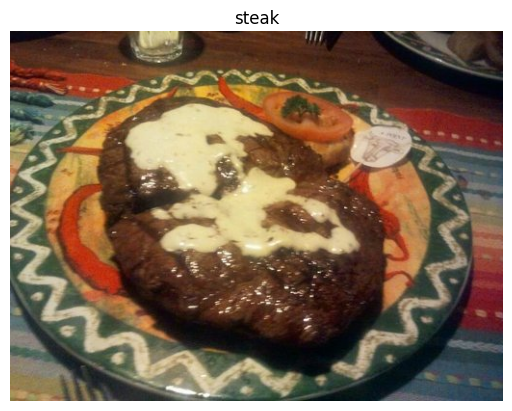

In [142]:
img = Image.open(img_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title(custom_train_dataset.classes[idx])
plt.show()

In [143]:
custom_train_loader = DataLoader(custom_train_dataset,
                                shuffle = True,
                                batch_size = 5)
custom_test_loader = DataLoader(custom_test_dataset,
                               shuffle = False,
                               batch_size = 5)

In [145]:
_img, _target = next(iter(custom_train_loader))

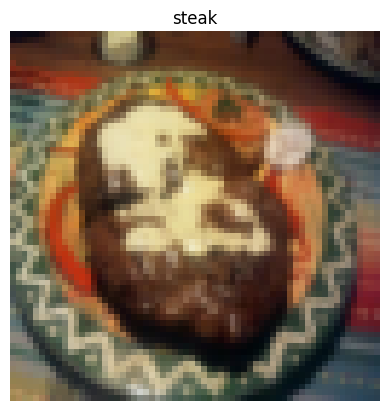

In [154]:
plt.imshow(_img[0].permute(1, 2, 0))
plt.title(custom_train_dataset.classes[_target[0]])
plt.axis(False)
plt.show()

In [61]:
64 * 64

4096

In [205]:
class FoodClassifierModel(torch.nn.Module):
    def __init__(self, in_features: int = 3, out_features: int = 3, hidden_units: int = 32,
                drop_units: int = 16):
        super(FoodClassifierModel, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.hidden_units = hidden_units 
        self.drop_units = drop_units

        self.convolutional_layer1 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.in_features,
                           out_channels = self.hidden_units,
                           padding = 0,
                           kernel_size = (3, 3),
                           stride = 1),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.hidden_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = (2, 2), stride = 2)
        )

        self.convolutional_layer2 = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels = self.hidden_units,
                           out_channels = self.drop_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.Conv2d(in_channels = self.drop_units,
                           out_channels = self.drop_units,
                           kernel_size = (3, 3),
                           stride = 1,
                           padding = 0),
            torch.nn.ReLU(inplace = True),
            torch.nn.MaxPool2d(kernel_size = (2, 2), stride = 2)
        )

        self.linear_layer = torch.nn.Sequential(
            torch.nn.Flatten(),
            torch.nn.Linear(in_features = self.drop_units * 13 * 13,
                           out_features = self.out_features)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.convolutional_layer1(x)
        print(x.shape)
        x = self.convolutional_layer2(x)
        print(x.shape)
        x = self.linear_layer(x)
        print(x.shape)
        return x

In [206]:
device = "mps" if torch.mps.is_available() else "cpu"

In [207]:
device

'mps'

In [208]:
model = FoodClassifierModel().to(device)
model

FoodClassifierModel(
  (convolutional_layer1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (convolutional_layer2): Sequential(
    (0): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2704, out_features=3, bias=True)
  )
)

In [209]:
with torch.inference_mode():
    pred = model(image.to(device))

pred

# image[0].shape

torch.Size([32, 32, 30, 30])
torch.Size([32, 16, 13, 13])
torch.Size([32, 3])


tensor([[ 0.0155,  0.0185, -0.0224],
        [ 0.0155,  0.0183, -0.0224],
        [ 0.0266,  0.0230, -0.0284],
        [ 0.0162,  0.0154, -0.0248],
        [ 0.0207,  0.0159, -0.0180],
        [ 0.0214,  0.0207, -0.0270],
        [ 0.0217,  0.0201, -0.0202],
        [ 0.0175,  0.0151, -0.0271],
        [ 0.0178,  0.0189, -0.0220],
        [ 0.0185,  0.0167, -0.0237],
        [ 0.0162,  0.0144, -0.0200],
        [ 0.0157,  0.0188, -0.0191],
        [ 0.0222,  0.0161, -0.0242],
        [ 0.0143,  0.0168, -0.0263],
        [ 0.0179,  0.0186, -0.0200],
        [ 0.0187,  0.0205, -0.0210],
        [ 0.0184,  0.0214, -0.0233],
        [ 0.0151,  0.0191, -0.0186],
        [ 0.0141,  0.0202, -0.0191],
        [ 0.0231,  0.0192, -0.0252],
        [ 0.0157,  0.0206, -0.0236],
        [ 0.0260,  0.0199, -0.0202],
        [ 0.0139,  0.0211, -0.0195],
        [ 0.0154,  0.0200, -0.0223],
        [ 0.0181,  0.0188, -0.0247],
        [ 0.0148,  0.0193, -0.0231],
        [ 0.0202,  0.0177, -0.0237],
 

In [189]:
16 * 16 * 16

4096

In [182]:
16 * 16

256